# Empirical Validation of Theory

---

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from networks.BP_network import BP_network
from networks.EWC_network import EWC_network
from networks.EFC_network import EFC_network
from networks.EHC_network import EHC_network
from src.dataloaders import ClassILMNIST2Task
from src.utils import dotdict

from tqdm import tqdm

## Config

In [2]:
config = {
    "lr": 5e-4,
    "batch_size": 256,
    "epochs": 10,
    "mode": "di",  # or "di"
    "num_workers": 0,
    "loss_fn": "ce", # "mse"
    "optimizer": "Adam",
    "scheduler": "CosineAnnealingLR",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "output_dir": "./outputs",
    "seed": 0,
    "target_lr": 1.0, # needs to be < time_constant_ratio
    "alpha_di": 0.0017,
    "alpha_I": 0.0017,
    "tau": 0.032,
    "dt_di": 0.02,
    "psi_lr": 0.1,
    "alpha_psi": 0.0,
    "time_constant_ratio": 0.2, # this param can be merged with dt_di
    "tmax_di": 500,
    "k_p": 2.0,
    "eps": 1e-4, # there is an interplay between dt_di and eps and between target_lr and eps
    "save": False,
    "importance_ewc": 4.0, # ewc params
    "beta_efc": 0.1, # efc params
    "flatten_imgs": True,
    "setting": "classIL2task", # domainIL, taskIL, classIL5task, classIL2task
    "peak": False, # saves the peak model based on cumulative accuracy and restores it after each task
    "layers": [784, 64, 64, 10],
    "num_tasks": 2,
    "classes_per_task": 5,
}

config = dotdict(config)

torch.manual_seed(config.seed)
np.random.seed(config.seed)

## Dataloaders – Class-IL 2-task Split-MNIST

In [3]:
dataloader = ClassILMNIST2Task(config)

train_loader_A, test_loader_A = dataloader.get_dataloaders(task_id=0)
train_loader_B, test_loader_combined = dataloader.get_dataloaders(task_id=1)

def split_loader(loader, keep_classes):
    """Return a DataLoader that contains only the given class indices."""
    data, targets = [], []
    for x, y in loader:
        idx = (y.argmax(1) >= keep_classes[0]) & (y.argmax(1) <= keep_classes[1])
        data.append(x[idx])
        targets.append(y[idx])
    if not data: return None
    dataset = TensorDataset(torch.cat(data), torch.cat(targets))
    return DataLoader(dataset, batch_size=config.batch_size,
                      shuffle=False, num_workers=config.num_workers, pin_memory=True)

test_loader_B = split_loader(test_loader_combined, [5,9])

print(f"Task A: {len(train_loader_A.dataset)} train, {len(test_loader_A.dataset)} test")
print(f"Task B: {len(train_loader_B.dataset)} train, {len(test_loader_B.dataset)} test_only")
print(f"Combined test: {len(test_loader_combined.dataset)}")

Task A: 30596 train, 5139 test
Task B: 29404 train, 4861 test_only
Combined test: 10000


## Train Task A on BP_network

In [4]:
# Initialize
bp_net_A = BP_network(config).to(config.device)
optimizer = optim.Adam(bp_net_A.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss()

def train_one_epoch(net, loader, opt, crit):
    net.train()
    total_loss = 0
    correct = 0
    for x, y in loader:
        x, y = x.to(config.device), y.to(config.device)
        y = y[:, :5]  # only first 5 classes
        opt.zero_grad()
        net.task_id = 0
        out = net(x)
        loss = crit(out, y.argmax(dim=1))
        loss.backward()
        opt.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == y.argmax(1)).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# Train Task A
epochs = 20
print("Training Task A (BP)...")
for epoch in range(epochs):
    loss, acc = train_one_epoch(bp_net_A, train_loader_A, optimizer, criterion)
    print(f"Epoch {epoch+1:02d} | Loss: {loss:.4f} | Acc: {acc:.4f}")

Training Task A (BP)...
Epoch 01 | Loss: 0.3549 | Acc: 0.8847
Epoch 02 | Loss: 0.0929 | Acc: 0.9727
Epoch 03 | Loss: 0.0670 | Acc: 0.9805
Epoch 04 | Loss: 0.0514 | Acc: 0.9854
Epoch 05 | Loss: 0.0418 | Acc: 0.9881
Epoch 06 | Loss: 0.0332 | Acc: 0.9910
Epoch 07 | Loss: 0.0279 | Acc: 0.9922
Epoch 08 | Loss: 0.0227 | Acc: 0.9935
Epoch 09 | Loss: 0.0194 | Acc: 0.9946
Epoch 10 | Loss: 0.0159 | Acc: 0.9963
Epoch 11 | Loss: 0.0128 | Acc: 0.9970
Epoch 12 | Loss: 0.0110 | Acc: 0.9975
Epoch 13 | Loss: 0.0087 | Acc: 0.9985
Epoch 14 | Loss: 0.0074 | Acc: 0.9988
Epoch 15 | Loss: 0.0060 | Acc: 0.9991
Epoch 16 | Loss: 0.0049 | Acc: 0.9996
Epoch 17 | Loss: 0.0041 | Acc: 0.9996
Epoch 18 | Loss: 0.0036 | Acc: 0.9997
Epoch 19 | Loss: 0.0029 | Acc: 0.9998
Epoch 20 | Loss: 0.0025 | Acc: 0.9999


## Copy Weights to All Methods & Reset Optimizers

In [5]:
def copy_weights(src_net, dst_net):
    dst_net.load_state_dict(deepcopy(src_net.state_dict()))

# Create all networks
ewc_net = EWC_network(config).to(config.device)
efc_net = EFC_network(config).to(config.device)
bp_net = BP_network(config).to(config.device)
ehc_net = EHC_network(config).to(config.device)

# Copy Task A weights
copy_weights(bp_net_A, ewc_net)
copy_weights(bp_net_A, efc_net)
copy_weights(bp_net_A, bp_net)
copy_weights(bp_net_A, ehc_net)

# Reset optimizers
config.lr = 1e-5
optimizers = {
    'ewc': optim.Adam(ewc_net.parameters(), lr=config.lr),
    'efc': optim.Adam(efc_net.parameters(), lr=config.lr),
    'bp':  optim.Adam(bp_net.parameters(), lr=config.lr),
    'ehc': optim.Adam(ehc_net.parameters(), lr=config.lr),
}

print("Weights copied, optimizers reset.")

Weights copied, optimizers reset.


## Compute Fisher & Hessian

In [6]:
ewc_net.task_id = 0
efc_net.task_id = 0
bp_net.task_id = 0
ehc_net.task_id = 0

ewc_net.complete_task(train_loader_A)
efc_net.complete_task(train_loader_A)
bp_net.complete_task(train_loader_A)
# ehc_net.complete_task(train_loader_A)

ewc_net.task_id = 1
efc_net.task_id = 1
bp_net.task_id = 1
ehc_net.task_id = 1

fisher_A = ewc_net._fisher
# hessian_A = ehc_net._hessian

## Train and evaluate on Task B

In [7]:
def evaluate_acc(net, loader, task_id, task_classes):
    net.eval()
    correct = total = 0
    start_idx, end_idx = task_classes[0], task_classes[1] + 1  # inclusive end
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(config.device), y.to(config.device)
            net.task_id = task_id
            out = net(x)  # Shape: [B, num_classes_so_far]
            
            # Slice only the heads for this task
            task_out = out[:, start_idx:end_idx]  # [B, 5]
            
            # Compute prediction within task subspace
            pred_rel = task_out.argmax(1)  # [0,4]
            pred_abs = pred_rel + start_idx  # Map to global labels: [5,9]
            
            true_labels = y.argmax(1)
            correct += (pred_abs == true_labels).sum().item()
            total += y.size(0)
    return correct / total if total else 0.0

In [8]:
nets = {
    'bp': bp_net,
    'ewc': ewc_net,
    'efc': efc_net,
    # 'EHC': ehc_net
}

weight_deltas = {name: [] for name in nets}  # List of dicts {param_name: delta_tensor} for first 5 batches
acc_logs = {name: {'acc_A': [], 'acc_B': [], 'combined': []} for name in nets}

def train_on_B(epochs=10):
    for name, net in nets.items():
        print(f"\nTraining {name} on Task B ...")
        opt = optimizers[name]
        net.train()
        batch_idx = 0

        # total batches = epochs × len(train_loader_B)
        total_batches = epochs * len(train_loader_B)
        pbar = tqdm(total=total_batches, desc=name, unit="batch")

        for epoch in range(epochs):
            for x, y in train_loader_B:
                x = x.to(config.device)
                y = y.to(config.device)
                net.task_id = 1

                # ---- store old parameters (only for the first 5 batches) ----
                if epoch == 0 and batch_idx < 5:
                    old_params = {n: p.clone().detach()
                                  for n, p in net.named_parameters() if p.requires_grad}

                # ---- forward / backward / step ----
                opt.zero_grad()
                y_hat = net(x)
                _ = net.calculate_loss(y_hat, y)
                net.backward(y)
                opt.step()

                # ---- weight-delta logging (first 5 batches) ----
                if epoch == 0 and batch_idx < 5:
                    delta = {n: p - old_params[n]
                             for n, p in net.named_parameters() if p.requires_grad}
                    weight_deltas[name].append(delta)

                # ---- accuracy logging (only when requested) ----
                if batch_idx % 10 == 0 or batch_idx == total_batches - 1:
                    acc_A      = evaluate_acc(net, test_loader_A,        task_id=0, task_classes=[0, 4])
                    acc_B      = evaluate_acc(net, test_loader_B,        task_id=1, task_classes=[5, 9])
                    combined   = evaluate_acc(net, test_loader_combined, task_id=1, task_classes=[0, 9])  # Class-IL

                    acc_logs[name]['acc_A'].append(acc_A)
                    acc_logs[name]['acc_B'].append(acc_B)
                    acc_logs[name]['combined'].append(combined)

                    pbar.set_postfix({
                        'A': f'{acc_A:.3f}',
                        'B': f'{acc_B:.3f}',
                        'Comb': f'{combined:.3f}'
                    })

                pbar.update(1)
                batch_idx += 1

        pbar.close()

train_on_B(epochs=10)

import pickle
with open('outputs/weight_deltas.pkl', 'wb') as f:
    pickle.dump(weight_deltas, f)
with open('outputs/acc_logs.pkl', 'wb') as f:
    pickle.dump(acc_logs, f)


Training bp on Task B ...


bp:   0%|          | 0/1150 [00:00<?, ?batch/s]

bp: 100%|██████████| 1150/1150 [00:08<00:00, 139.90batch/s, A=0.986, B=0.801, Comb=0.640]



Training ewc on Task B ...


ewc: 100%|██████████| 1150/1150 [00:08<00:00, 134.92batch/s, A=0.986, B=0.799, Comb=0.638]



Training efc on Task B ...


efc:   6%|▌         | 69/1150 [00:44<19:58,  1.11s/batch, A=0.992, B=0.213, Comb=0.555]

KeyboardInterrupt: 

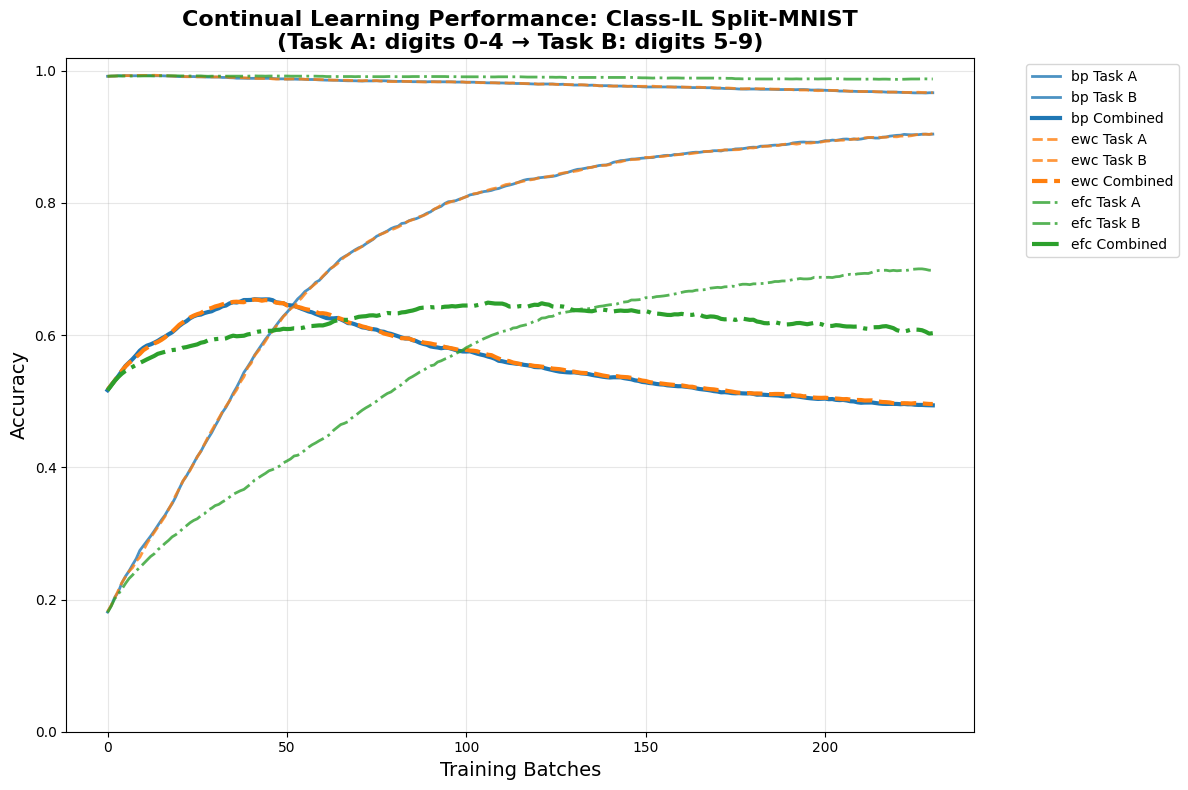


FINAL ACCURACIES (after Task B training)
bp       | A: 0.967 | B: 0.904 | Combined: 0.494
ewc      | A: 0.967 | B: 0.905 | Combined: 0.496
efc      | A: 0.988 | B: 0.698 | Combined: 0.603


In [9]:
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot each method
colors = {'bp': 'tab:blue', 'ewc': 'tab:orange', 'efc': 'tab:green', 'ehc': 'tab:red'}
linestyles = {'bp': '-', 'ewc': '--', 'efc': '-.', 'ehc': ':'}

for name in nets.keys():
    # Interpolate to same length for smooth plotting (if eval_every_n_batches > 1)
    x = np.arange(len(acc_logs[name]['acc_A']))
    
    ax.plot(x, acc_logs[name]['acc_A'], label=f'{name} Task A', 
            color=colors[name], linestyle=linestyles[name], linewidth=2, alpha=0.8)
    ax.plot(x, acc_logs[name]['acc_B'], label=f'{name} Task B', 
            color=colors[name], linestyle=linestyles[name], linewidth=2, alpha=0.8)
    ax.plot(x, acc_logs[name]['combined'], label=f'{name} Combined', 
            color=colors[name], linestyle=linestyles[name], linewidth=3, alpha=1.0)

# Formatting
ax.set_xlabel('Training Batches', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_title('Continual Learning Performance: Class-IL Split-MNIST\n'
             '(Task A: digits 0-4 → Task B: digits 5-9)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print final accuracies
print("\n" + "="*60)
print("FINAL ACCURACIES (after Task B training)")
print("="*60)
for name in nets.keys():
    print(f"{name:8s} | A: {acc_logs[name]['acc_A'][-1]:.3f} | "
          f"B: {acc_logs[name]['acc_B'][-1]:.3f} | Combined: {acc_logs[name]['combined'][-1]:.3f}")
print("="*60)